# Dự đoán bệnh tiểu đường - Phân tích dựa trên dữ liệu bệnh tiểu đường Pima Indians

## 1. Định nghĩa vấn đề (Define Problem)

* **Mô tả:**
    * Bộ dữ liệu thống kê về bệnh tiểu đường bao gồm 768 mẫu được thu thập từ phụ nữ người Pima Indians sinh sống gần Phoenix, Arizona, Hoa Kỳ
    * Các mẫu được đo với 8 thông số bao gồm: 
        1. Số lần mang thai - Number of times pregnant (lần)
        2. Nồng độ glucose huyết tương sau 2 giờ trong xét nghiệm dung nạp glucose đường uống - Plasma glucose concentration a 2 hours in an oral glucose tolerance test (mg/dL)
        3. Huyết áp tâm trương - Diastolic blood pressure (mmHg)
        4. Độ dày nếp gấp da cơ tam đầu - Triceps skin fold thickness (mm)
        5. Nồng độ huyết thanh insullin sau 2 giờ - 2-Hour serum insulin (μU/ml)
        6. Chỉ số khối cơ thể - Body mass index (cân nặng (kg)) / (chiều cao (m²))
        7. Hàm phả hệ bệnh tiểu đường - Diabetes pedigree function
        8. Tuổi - Age (năm)
        9. Hệ số phân loại (0: Không mắc bệnh; 1: Mắc bệnh tiểu đường)
* **Dữ liệu đầu vào:**
    * Preg - Pregnancies (times)
    * Glucose - Glucose (mg/dL)
    * BloodP - BloodPressure (mmHg)
    * Skin - SkinThickness (mm)
    * Insulin - Insulin (μU/ml)
    * BMI - BodyMassIndex (kg/m²)
    * DPF - DiabetesPedigreeFunction
    * Age - Age (years)
* **Kết quả đầu ra:** Outcome (0: Không mắc bệnh; 1: Mắc bệnh tiểu đường)
* **Dạng bài toán:** Phân loại nhị phân (Binary Classification)



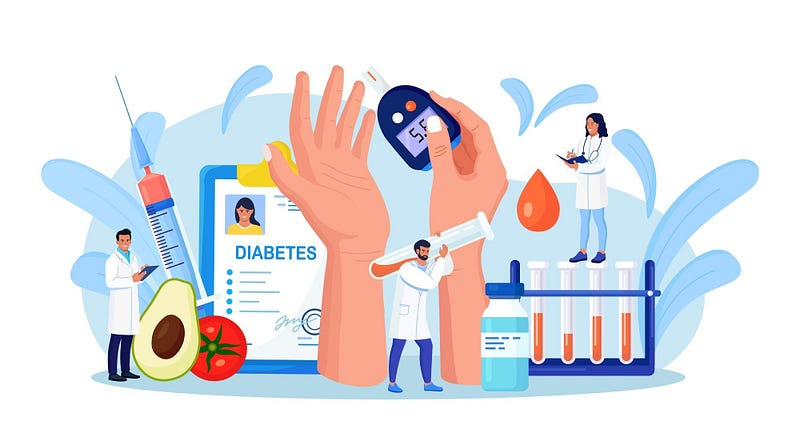

## 2. Chuẩn bị vấn đề (Prepare Problem)
### 2.1. Khai báo thư viện (Load Libraries)

In [1]:
# Load libraries
import os
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
%matplotlib inline
warnings.filterwarnings("ignore")

### 2.2 Nạp dữ liệu đầu vào (Load Input Dataset)

In [2]:
dataset_path = "data/pima-indians-diabetes.csv"
dataset_names = ["Preg","Glucose","BloodP","Skin","Insulin","BMI","DPF","Age","Outcome"]
dataset = pd.read_csv(dataset_path, names = dataset_names)
display.display(dataset)

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## 3. Phân tích dữ liệu (Analyze Data)
### 3.1. Thống kê mô tả (Descriptive Statistics)
#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [3]:
#Shape
print(f'+ Shape: {dataset.shape}')
# Types
print(f'+ Data types: \n{dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(dataset.head(5))
display.display(dataset.tail(5))
# info
dataset.info()

+ Shape: (768, 9)
+ Data types: 
Preg         int64
Glucose      int64
BloodP       int64
Skin         int64
Insulin      int64
BMI        float64
DPF        float64
Age          int64
Outcome      int64
dtype: object
+ Contents: 


,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Preg     768 non-null    int64  
 1   Glucose  768 non-null    int64  
 2   BloodP   768 non-null    int64  
 3   Skin     768 non-null    int64  
 4   Insulin  768 non-null    int64  
 5   BMI      768 non-null    float64
 6   DPF      768 non-null    float64
 7   Age      768 non-null    int64  
 8   Outcome  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét chung:**
* Bộ dữ liệu có 9 tính chất phân loại
* Giá trị của tính về tỉ số BMI và DPF là số thực (float64), giá trị các thuộc tính còn lại đều là số nguyên (int64)
* Bộ dữ liệu có 768 dòng
* Thuộc tính Outcome dùng để phân biệt người mắc bệnh (1) hoặc không mắc bệnh (0)
* Không tồn tại dữ liệu null

#### (2) **Kiểm tra tính toàn vẹn và nhất quán của dữ liệu**

In [4]:
has_null = dataset.isnull().sum().any()
has_nan = dataset.isna().sum().any()
duplicate = dataset.duplicated().sum()

print(f'Kiểm tra tính toàn vẹn dữ liệu:')
print(f'+ Tồn tại giá trị Null: {has_null}')
if has_null:
    display.display(dataset[dataset.isnull().any(axis=1)])
print(f'+ Tồn tại giá trị NaN: {has_nan}')
if has_nan:
    display.display(dataset[dataset.isna().any(axis=1)])
print(f'+ Số mẫu dữ liệu trùng nhau: {duplicate}')
if duplicate > 0:
    display.display(dataset[dataset.duplicated()])
    

Kiểm tra tính toàn vẹn dữ liệu:
+ Tồn tại giá trị Null: False
+ Tồn tại giá trị NaN: False
+ Số mẫu dữ liệu trùng nhau: 0


**Nhận xét:** Bộ dữ liệu là khá toàn vẹn và không tồn tại giá trị null, NaN hay có dòng trùng lặp

* **Kiểm tra missing value thực sự và giá trị 0 bất hợp lý**

In [5]:
# ── 2. Kiểm tra missing values thực sự và giá trị 0 bất hợp lý ──
print("Kiểm tra missing data trên dữ liệu:")
# Các cột không thể có giá trị 0 trong thực tế
invalid_zero_cols = ['Glucose', 'BloodP', 'Skin', 'Insulin', 'BMI']

for col in invalid_zero_cols:
    n_zeros = (dataset[col] == 0).sum()
    pct = n_zeros / len(dataset) * 100
    print(f"{col:10s}: {n_zeros:4d} giá trị 0  ({pct:.1f}%)")

Kiểm tra missing data trên dữ liệu:
Glucose   :    5 giá trị 0  (0.7%)
BloodP    :   35 giá trị 0  (4.6%)
Skin      :  227 giá trị 0  (29.6%)
Insulin   :  374 giá trị 0  (48.7%)
BMI       :   11 giá trị 0  (1.4%)


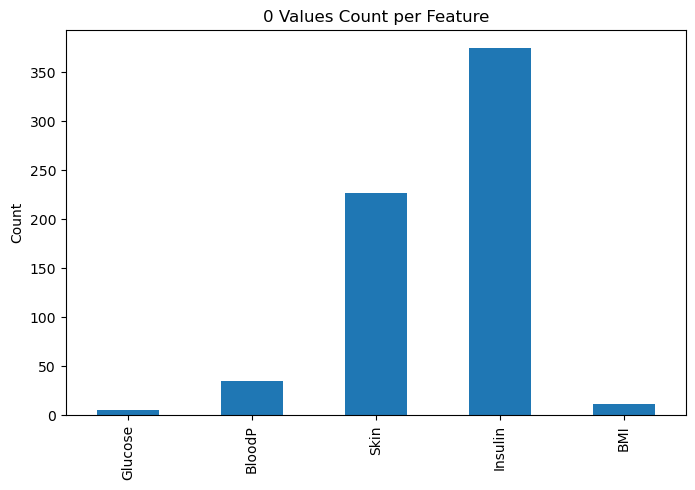

In [6]:
# Trực quan hóa các missing data
missing_counts = (dataset[invalid_zero_cols] == 0).sum()
missing_counts.plot(kind='bar', figsize=(8,5))

plt.title("0 Values Count per Feature")
plt.ylabel("Count")
plt.show()

**Nhận xét:** Các thuộc tính sinh học Glucose, BloodP, Skin, Insulin hay BMI có số giá trị bằng 0 còn lại là điều bất thường (Đối với Preg thì giá trị 0 là điều bình thường (chưa mang thai)). Trong đó Insulin chứa nhiều missing data nhất (gần phân nửa) 

* **Phát hiện các điểm outliers (điểm ngoại lệ) bằng phương pháp IQR**

    IQR (Interquartile Range) -  Khoảng tứ phân vị, là một thước đo độ phân tán của dữ liệu.
    $$IQR = Q_3 − Q_1$$

    Trong đó $Q_1$ là phân vị thứ 25% (tứ phân vị thứ nhất) và $Q_3$ là phân vị thứ 75% (tứ phân vị thứ ba).
    
    Quy tắc phổ biến nhất là bất kỳ giá trị nào nằm ngoài khoảng sau đều bị coi là outlier:

    + Giới hạn dưới: $Q_1 − 1.5 × IQR$

    + Giới hạn trên: $Q_3 + 1.5 × IQR$

In [7]:
# ── 5. Phát hiện outlier bằng IQR ──
print("Phát hiện các điểm outliers bằng phương pháp IQR")

features = dataset.columns[:-1]
for col in features:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((dataset[col] < lower) | (dataset[col] > upper)).sum()
    pct   = n_out / len(dataset) * 100
    print(f"{col:10s}: {n_out:3d} outliers ({pct:.1f}%)  "
          f"[lower={lower:.1f}, upper={upper:.1f}]")

Phát hiện các điểm outliers bằng phương pháp IQR
Preg      :   4 outliers (0.5%)  [lower=-6.5, upper=13.5]
Glucose   :   5 outliers (0.7%)  [lower=37.1, upper=202.1]
BloodP    :  45 outliers (5.9%)  [lower=35.0, upper=107.0]
Skin      :   1 outliers (0.1%)  [lower=-48.0, upper=80.0]
Insulin   :  34 outliers (4.4%)  [lower=-190.9, upper=318.1]
BMI       :  19 outliers (2.5%)  [lower=13.3, upper=50.6]
DPF       :  29 outliers (3.8%)  [lower=-0.3, upper=1.2]
Age       :   9 outliers (1.2%)  [lower=-1.5, upper=66.5]


**Nhận xét:**  Đa số các thuộc tính đang chứa các điểm ngoại lệ

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count (count): Đếm
+ Mean (mean): Giá trị trung bình
+ Standard Deviation (std): Độ lệch chuẩn 
+ Minimum Value (min): giá trị tối thiểu
+ 25th Percentile (25%): Tứ phân vị thứ nhất
+ 50th Percentile (Median 50%): Trung vị
+ 75th Percentile (75%): Tứ phân vị thứ 3
+ Maximum Value (max): giá trị tối đa

In [8]:
description = dataset.describe().round(2).T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Preg,768.0,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.0,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodP,768.0,69.11,19.36,0.00,62.00,72.00,80.00,122.00
Skin,768.0,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.0,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.0,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DPF,768.0,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.0,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


**Nhận xét:**
* Phân phối ở thuộc tính Insulin có độ lệch lớn (115.244002)
* Với outcome phân loại có mean = 0.35 cho thấy tỉ lệ giữa 2 nhóm chưa cân bằng

#### (4) **Phân tích Skewness (độ lệch) và Kurtosis (độ nhọn)**

In [9]:
print("Độ lệch của các thuộc tính")
display.display(dataset.skew())
print("Dộ nhọn của các thuộc tính")
display.display(dataset.kurt())


Độ lệch của các thuộc tính


Preg       0.901674
Glucose    0.173754
BloodP    -1.843608
Skin       0.109372
Insulin    2.272251
BMI       -0.428982
DPF        1.919911
Age        1.129597
Outcome    0.635017
dtype: float64

Dộ nhọn của các thuộc tính


Preg       0.159220
Glucose    0.640780
BloodP     5.180157
Skin      -0.520072
Insulin    7.214260
BMI        3.290443
DPF        5.594954
Age        0.643159
Outcome   -1.600930
dtype: float64

#### (5) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

In [10]:
counts = dataset["Outcome"].value_counts()
percent = dataset["Outcome"].value_counts(normalize=True) * 100
result = counts.to_frame(name="Count")
result["Percent (%)"] = percent
display.display(result)

# Giá trị trung bình dựa trên Outcome
pivot_table = dataset.groupby("Outcome").mean().T
pivot_table.columns = ["Mean Outcome=0", "Mean Outcome=1"]
pivot_table = pivot_table.reset_index()
pivot_table["Δmean"] = pivot_table["Mean Outcome=1"] - pivot_table["Mean Outcome=0"]
display.display(pivot_table)

,Count,Percent (%)
Outcome,,
0,500,65.104167
1,268,34.895833


,index,Mean Outcome=0,Mean Outcome=1,Δmean
0,Preg,3.298000,4.865672,1.567672
1,Glucose,109.980000,141.257463,31.277463
2,BloodP,68.184000,70.824627,2.640627
3,Skin,19.664000,22.164179,2.500179
4,Insulin,68.792000,100.335821,31.543821
5,BMI,30.304200,35.142537,4.838337
6,DPF,0.429734,0.550500,0.120766
7,Age,31.190000,37.067164,5.877164


**Nhận xét:**
* Dữ liệu được phân loại những theo 1 (dành cho phụ nữ mắc bệnh tiểu đường) và 0 (dành cho phụ nữ bình thường)
* Có tộng cổng 500 mẫu không mắc bệnh và 268 mẫu có mắc bệnh
* Glucose và Insulin có $Δ mean$ lớn 

#### (6) **Mối tương quan giữa các tính chất (Correlations)**

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả. 

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu của bạn. 

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

In [11]:
correlations = dataset.corr(method='pearson')
display.display(correlations)

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
Preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodP,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
Skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DPF,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


**Nhận xét:**
* Đa số các cặp thuộc tính có mức độ tương quan khá thấp < 0.4
* Cặp có mức độ tương quan trung bình như (Preg - Age) = 0.544341 và (Glucose - Outcome) = 0.466581

#### (7) **Kiểm định Mann-Whitney U**

In [12]:
feature_cols = ['Preg', 'Glucose', 'BloodP', 'Skin',
                'Insulin', 'BMI', 'DPF', 'Age']

results = []
for col in feature_cols:
    group0 = dataset[dataset['Outcome'] == 0][col]
    group1 = dataset[dataset['Outcome'] == 1][col]
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    results.append({
        'Đặc trưng': col,
        'U-statistic': round(stat, 2),
        'p-value': round(p, 6),
        'Kết luận': 'Có ý nghĩa' if p < 0.05 else 'Không có ý nghĩa'
    })

df_result = pd.DataFrame(results)
display.display(df_result)

,Đặc trưng,U-statistic,p-value,Kết luận
0,Preg,50985.0,0.000000,Có ý nghĩa
1,Glucose,28390.5,0.000000,Có ý nghĩa
2,BloodP,55414.5,0.000076,Có ý nghĩa
3,Skin,59814.0,0.012962,Có ý nghĩa
4,Insulin,61926.5,0.065660,Không có ý nghĩa
5,BMI,41866.0,0.000000,Có ý nghĩa
6,DPF,52769.0,0.000001,Có ý nghĩa
7,Age,41950.0,0.000000,Có ý nghĩa


### 3.2. Hiển thị dữ liệu (Visualize Data)
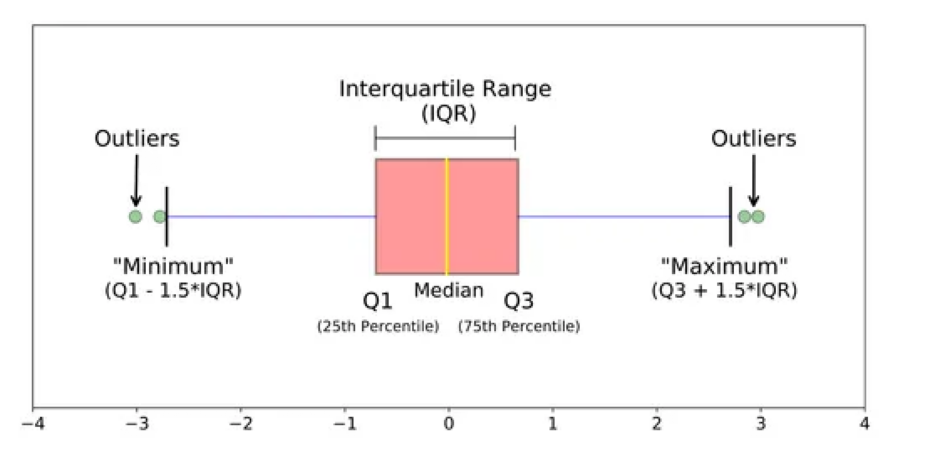

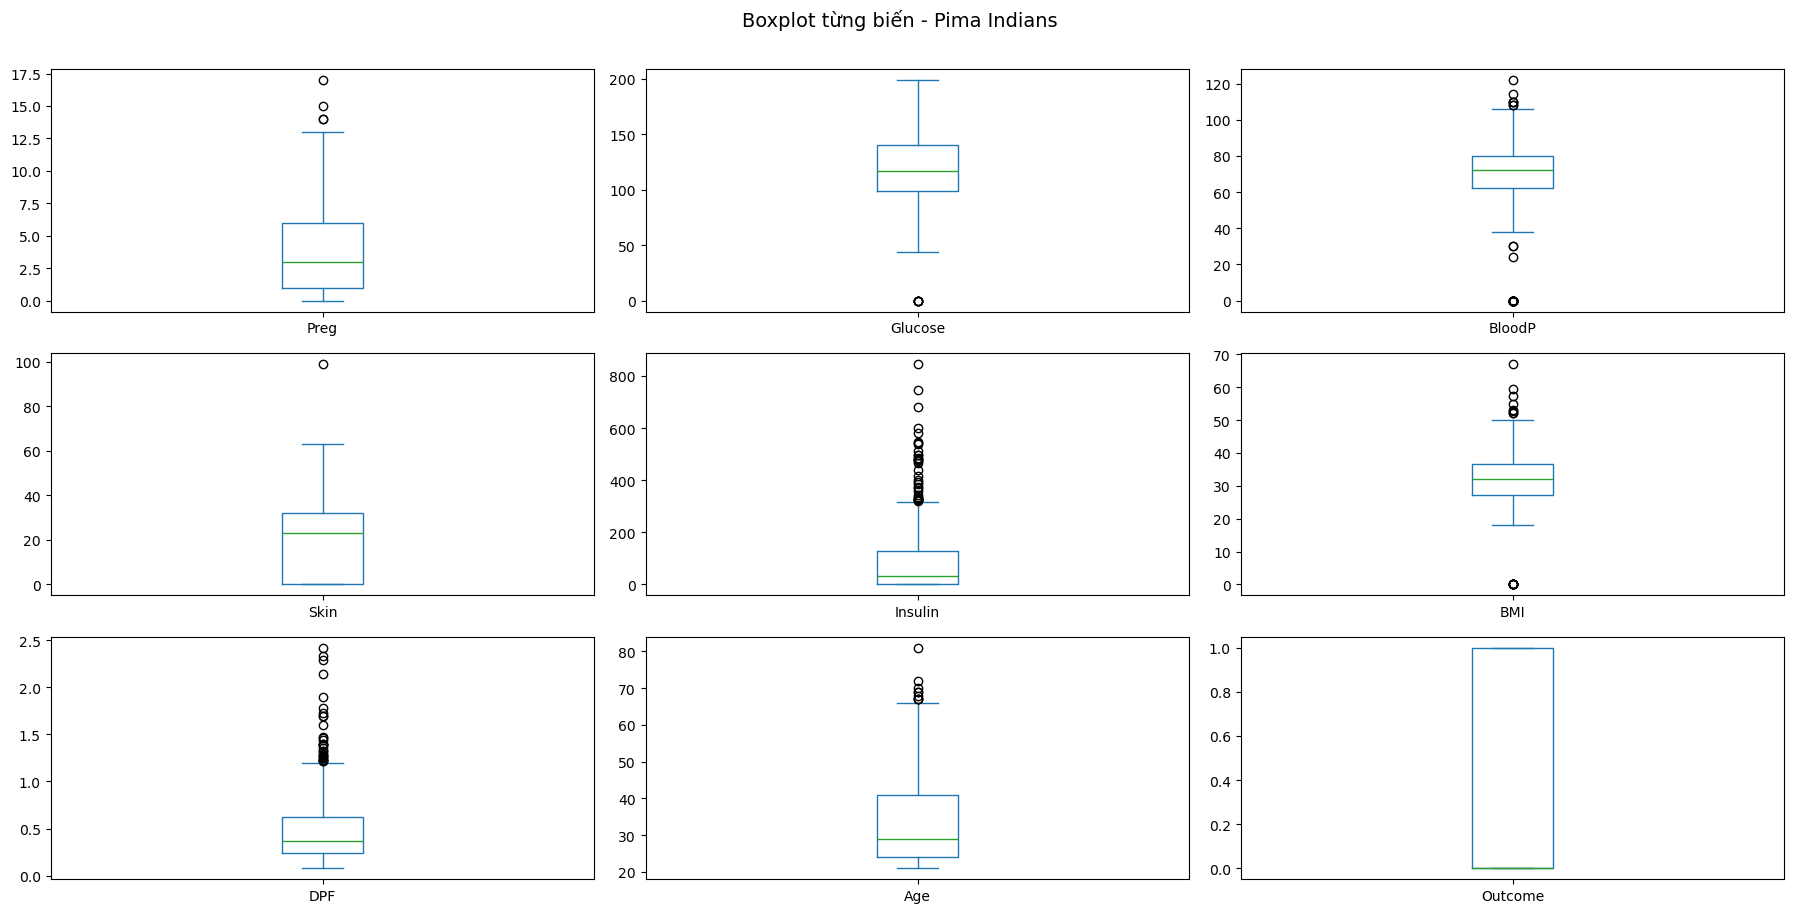

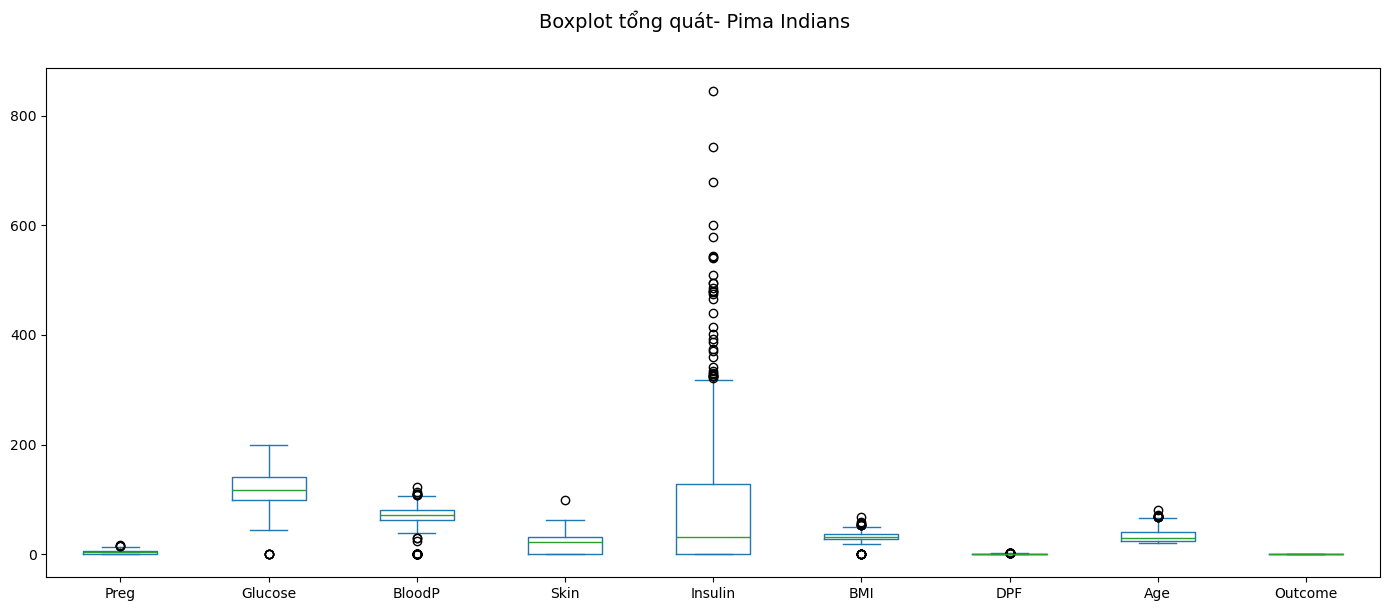

In [13]:
# boxplot từng biến
dataset.plot(kind='box', subplots=True, layout=(3,3),
             sharex=False, sharey=False, figsize=(18,9))
plt.suptitle('Boxplot từng biến - Pima Indians', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#boxplot tổng quát
dataset.plot(kind='box', figsize=(14,6))
plt.suptitle('Boxplot tổng quát- Pima Indians', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()



**Nhận xét:**
* Độ trải rộng các giá trị của các thuộc tính có sự khác biệt nhau
* Các thuộc tính có tồn tại các điểm ngoại lệ (Outliers)
* Đánh giá dựa trên của thuộc tính:
    + Preg: lệch phải khá ít
    + Glucose: Nhìn chung là khá cân bằng
    + BloodP: lệch trái khá ít
    + Skin: lệch phải khá lớn
    + Insulin: Có độ phấn tán khá rộng, độ lệch ph lớn, có rất nhiều outliers
    + BMI: Nhìn chung là khá cân bằng, độ phân tán khá nhỏ
    + DPF: lệch phải lớn, độ phân tán rất nhỏ, có nhiều outtliers
    + Age: có độ lệch phải lớn
    + Outcome: Chủ yếu là 0 và 1

#### Biểu đồ Histogram

array([[<Axes: title={'center': 'Preg'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodP'}>],
       [<Axes: title={'center': 'Skin'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DPF'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

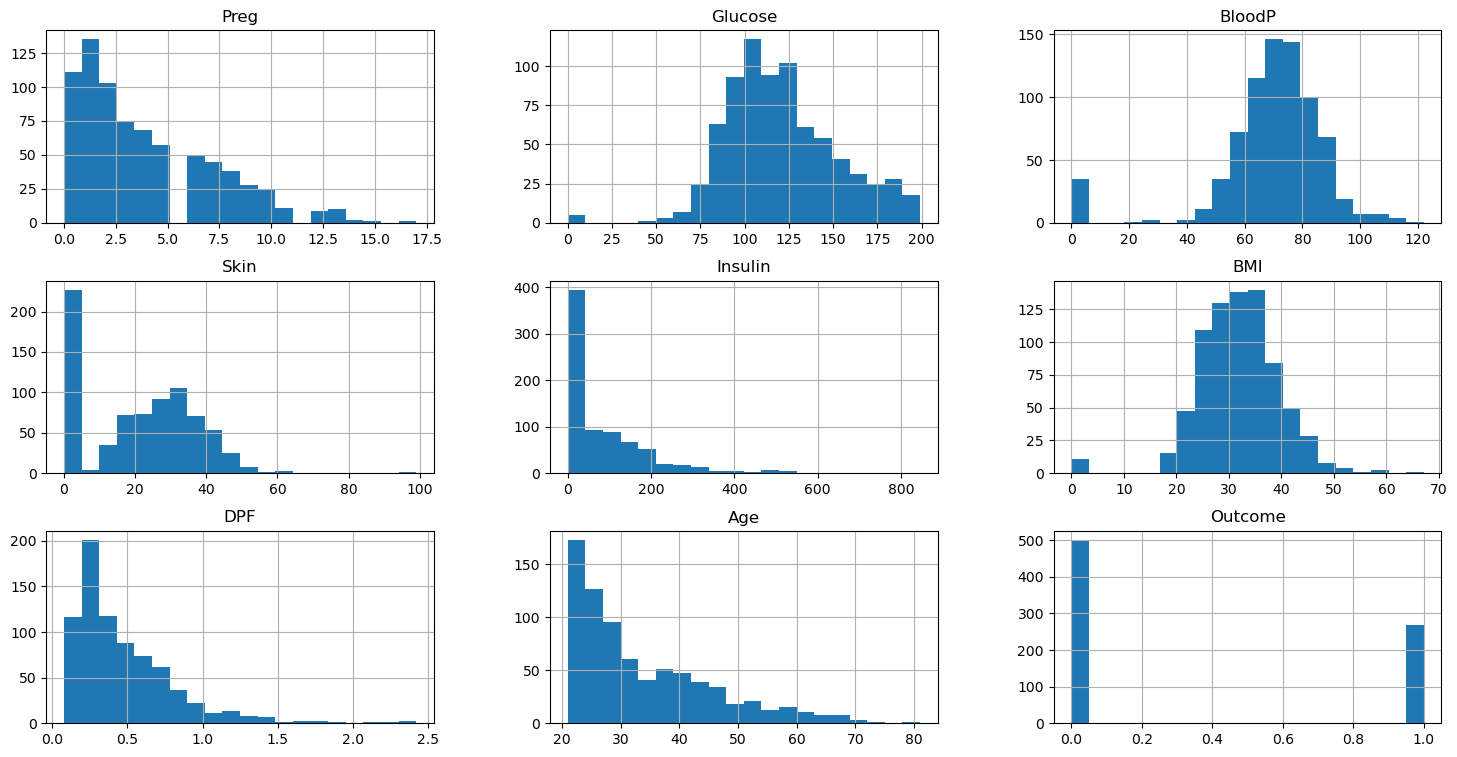

In [14]:
dataset.hist(bins = 20, layout=(3,3), sharex=False, sharey=False, figsize=(18,9))

#### (2) Hiển thị nhiều tính chất (Multivariate Plots)


array([[<Axes: xlabel='Preg', ylabel='Preg'>,
        <Axes: xlabel='Glucose', ylabel='Preg'>,
        <Axes: xlabel='BloodP', ylabel='Preg'>,
        <Axes: xlabel='Skin', ylabel='Preg'>,
        <Axes: xlabel='Insulin', ylabel='Preg'>,
        <Axes: xlabel='BMI', ylabel='Preg'>,
        <Axes: xlabel='DPF', ylabel='Preg'>,
        <Axes: xlabel='Age', ylabel='Preg'>,
        <Axes: xlabel='Outcome', ylabel='Preg'>],
       [<Axes: xlabel='Preg', ylabel='Glucose'>,
        <Axes: xlabel='Glucose', ylabel='Glucose'>,
        <Axes: xlabel='BloodP', ylabel='Glucose'>,
        <Axes: xlabel='Skin', ylabel='Glucose'>,
        <Axes: xlabel='Insulin', ylabel='Glucose'>,
        <Axes: xlabel='BMI', ylabel='Glucose'>,
        <Axes: xlabel='DPF', ylabel='Glucose'>,
        <Axes: xlabel='Age', ylabel='Glucose'>,
        <Axes: xlabel='Outcome', ylabel='Glucose'>],
       [<Axes: xlabel='Preg', ylabel='BloodP'>,
        <Axes: xlabel='Glucose', ylabel='BloodP'>,
        <Axes: xlabel='Blood

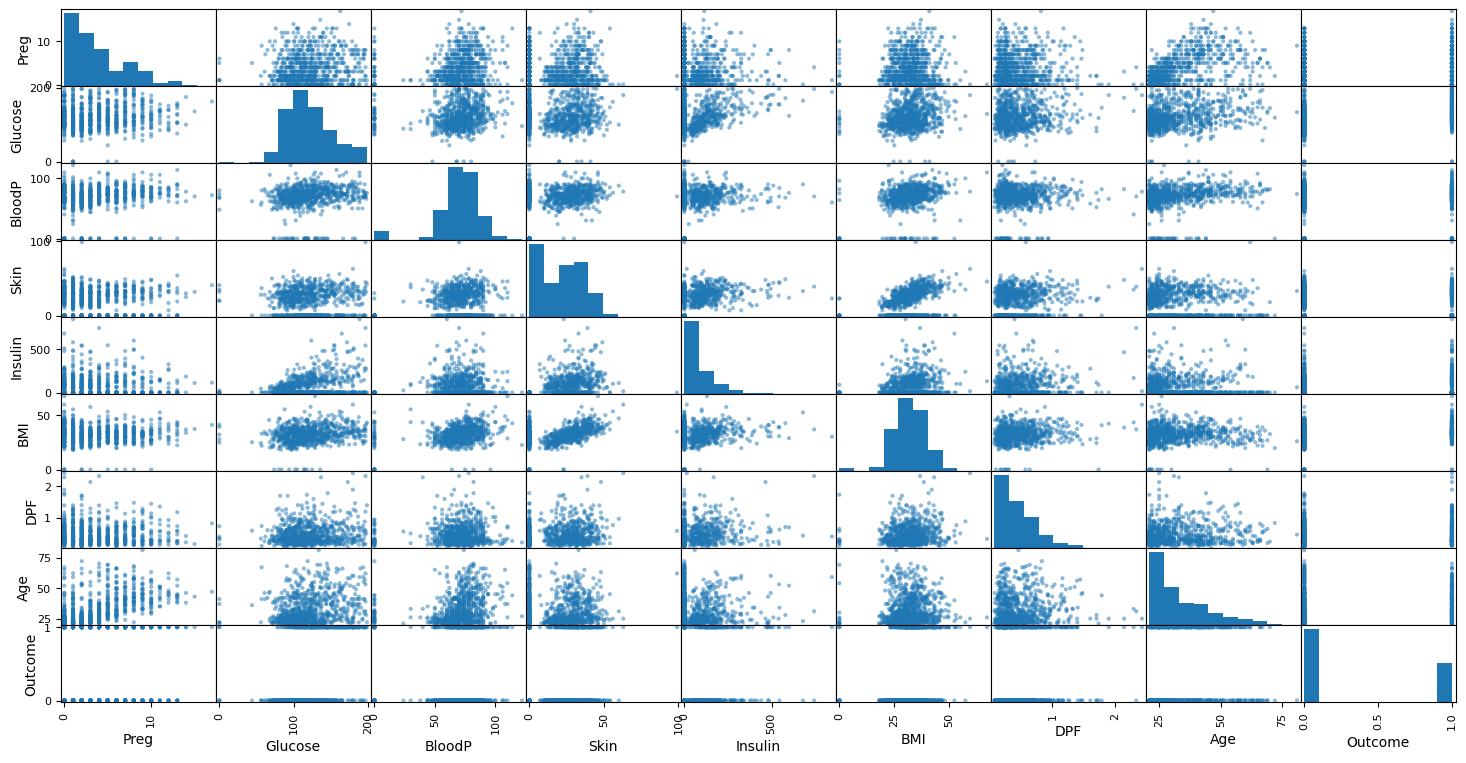

In [15]:
pd.plotting.scatter_matrix(dataset, figsize=(18,9))

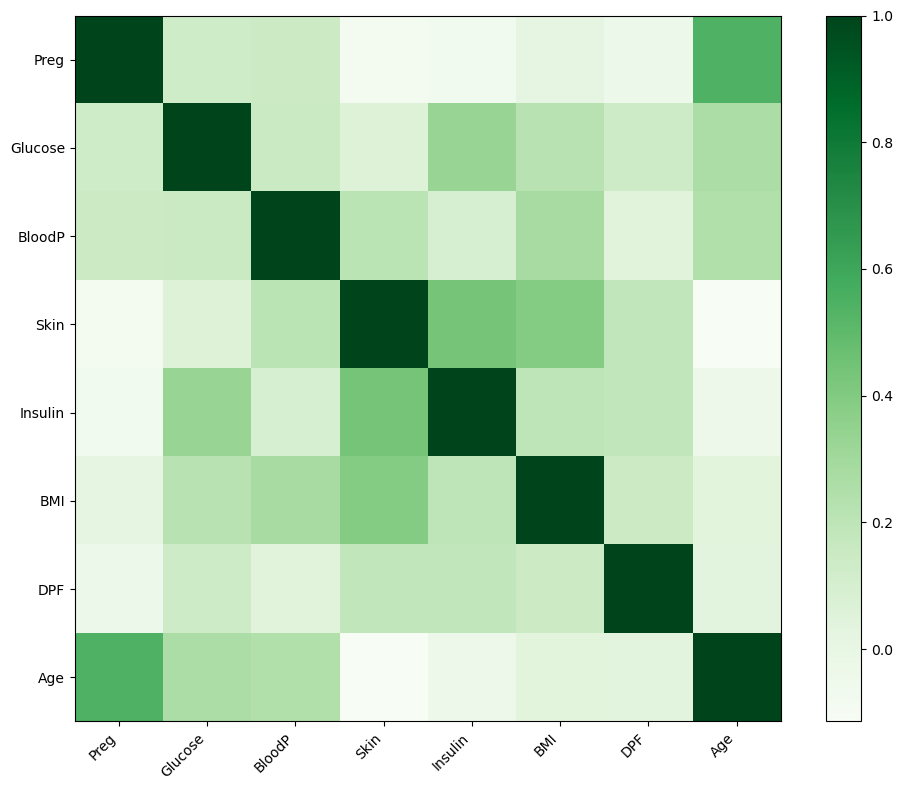

In [16]:
cols = list(dataset.columns[:-1])
n = len(cols)

corr_matrix = dataset[cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='Greens')
plt.colorbar()
plt.xticks(np.arange(n), cols, rotation=45, ha='right')
plt.yticks(np.arange(n), cols)
plt.tight_layout()
plt.show()

**Nhận xét:**
* Các tính chất có độ tương quan khá thấp
* Cặp tinh chất có độ tương quan trung bình: (Preg-Age)

## 4. Chuẩn bị dữ liệu (Prepare Data)
### 4.1. Làm sạch dữ liệu (Data Cleaning)
#### (1) **Tạo bảng dữ liệu làm sạch**
* Chỉ giữ lại các cột input, output

In [17]:
dataset_clean = dataset.copy()
display.display(dataset_clean)

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### (2) **Xóa dữ liệu trùng nhau** 

In [18]:
display.display(dataset[dataset.duplicated()])

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome


In [19]:
dataset_clean.drop_duplicates(ignore_index=True, inplace=True)
dataset_clean

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### (3) **Xử lý giá trị rỗng, không hợp lệ**


In [20]:
has_null_cl = dataset_clean.isnull().sum().any()
has_nan_cl  = dataset_clean.isna().sum().any()
print(f'+ Có giá trị Null: {has_null_cl}')
if has_null_cl:
    display.display(dataset_clean[dataset_clean.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan_cl}')
if has_nan_cl:
    display.display(dataset_clean[dataset_clean.isna().any(axis=1)])

+ Có giá trị Null: False
+ Có giá trị Nan: False


### 4.2. Biến đổi dữ liệu (Data Transforms)
#### (1) **Chuyển đổi dữ liệu danh mục thành dữ liệu số**


In [21]:
class_encoder = LabelEncoder()
class_encoder.fit(dataset_clean['Outcome'])
class_names = class_encoder.classes_
print(class_names)

[0 1]


In [22]:
dataset_clean["Outcome"] = class_encoder.transform(dataset_clean["Outcome"])
dataset_clean

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### (2) Xử lý giá trị thiếu (missing values)

In [23]:
cols_to_impute = ['Glucose', 'BloodP', 'Skin', 'Insulin', 'BMI']
# Đánh dấu giá trị 0 thành NaN trước
dataset_clean[cols_to_impute] = dataset_clean[cols_to_impute].replace(0, np.nan)

# Impute bằng median
imputer = SimpleImputer(strategy='median')
dataset_clean[cols_to_impute] = imputer.fit_transform(dataset_clean[cols_to_impute])

##Kiểm tra lại
# Kiểm tra sau imputation
print("Số giá trị 0 còn lại sau imputation:")
print((dataset_clean[cols_to_impute] == 0).sum())
print("Tổng:", (dataset_clean[cols_to_impute] == 0).sum().sum())

Số giá trị 0 còn lại sau imputation:
Glucose    0
BloodP     0
Skin       0
Insulin    0
BMI        0
dtype: int64
Tổng: 0


### (3) Xử lý các giá trị ngoại lệ (outliers)

In [24]:
feature_cols = ['Preg', 'Glucose', 'BloodP', 'Skin','Insulin', 'BMI', 'DPF', 'Age']

# Xử lý outlier
outlier_report = []
for col in feature_cols:
    Q1 = dataset_clean[col].quantile(0.25)
    Q3 = dataset_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_before = ((dataset_clean[col] < lower) | (dataset_clean[col] > upper)).sum()
    dataset_clean[col] = dataset_clean[col].clip(lower=lower, upper=upper)
    
    outlier_report.append({
        'Đặc trưng': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Giới hạn dưới': round(lower, 2),
        'Giới hạn trên': round(upper, 2),
        'Số điểm clip': n_before
    })

df_report = pd.DataFrame(outlier_report)
print(df_report.to_string(index=False))
print(f"Tổng số điểm bị clip: {df_report['Số điểm clip'].sum()}")

# Kiểm tra sau khi clip
print("\nKiểm tra sau xử lý (phải = 0)")
for col in feature_cols:
    Q1 = dataset_clean[col].quantile(0.25)
    Q3 = dataset_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((dataset_clean[col] < lower) | (dataset_clean[col] > upper)).sum()
    print(f"{col}: {n_outlier} outlier")

Đặc trưng     Q1     Q3   IQR  Giới hạn dưới  Giới hạn trên  Số điểm clip
     Preg   1.00   6.00  5.00          -6.50          13.50             4
  Glucose  99.75 140.25 40.50          39.00         201.00             0
   BloodP  64.00  80.00 16.00          40.00         104.00            14
     Skin  25.00  32.00  7.00          14.50          42.50            87
  Insulin 121.50 127.25  5.75         112.88         135.88           346
      BMI  27.50  36.60  9.10          13.85          50.25             8
      DPF   0.24   0.63  0.38          -0.33           1.20            29
      Age  24.00  41.00 17.00          -1.50          66.50             9
Tổng số điểm bị clip: 497

Kiểm tra sau xử lý (phải = 0)
Preg: 0 outlier
Glucose: 0 outlier
BloodP: 0 outlier
Skin: 0 outlier
Insulin: 0 outlier
BMI: 0 outlier
DPF: 0 outlier
Age: 0 outlier


### (4) Chia tập dữ liệu thực nghiệm

Khi học tập từ dữ liệu, có thể dùng bảng dữ liệu ở dạng DataFrame hoặc numpy. Để tối ưu tốc độ của việc học của mô hình nhanh hơn ta cần chuyển dữ liệu về DataFrame sang numpy array.

In [25]:
# Chuyển đổi dữ liệu sang dạng numpy array với Input (X_data), Output(y_data)
X_data = dataset_clean.drop('Outcome', axis=1).values
y_data = dataset_clean['Outcome'].values
X_data.shape, y_data.shape
print(X_data[:10, :])
print(y_data[:10])


[[6.00000e+00 1.48000e+02 7.20000e+01 3.50000e+01 1.25000e+02 3.36000e+01
  6.27000e-01 5.00000e+01]
 [1.00000e+00 8.50000e+01 6.60000e+01 2.90000e+01 1.25000e+02 2.66000e+01
  3.51000e-01 3.10000e+01]
 [8.00000e+00 1.83000e+02 6.40000e+01 2.90000e+01 1.25000e+02 2.33000e+01
  6.72000e-01 3.20000e+01]
 [1.00000e+00 8.90000e+01 6.60000e+01 2.30000e+01 1.12875e+02 2.81000e+01
  1.67000e-01 2.10000e+01]
 [0.00000e+00 1.37000e+02 4.00000e+01 3.50000e+01 1.35875e+02 4.31000e+01
  1.20000e+00 3.30000e+01]
 [5.00000e+00 1.16000e+02 7.40000e+01 2.90000e+01 1.25000e+02 2.56000e+01
  2.01000e-01 3.00000e+01]
 [3.00000e+00 7.80000e+01 5.00000e+01 3.20000e+01 1.12875e+02 3.10000e+01
  2.48000e-01 2.60000e+01]
 [1.00000e+01 1.15000e+02 7.20000e+01 2.90000e+01 1.25000e+02 3.53000e+01
  1.34000e-01 2.90000e+01]
 [2.00000e+00 1.97000e+02 7.00000e+01 4.25000e+01 1.35875e+02 3.05000e+01
  1.58000e-01 5.30000e+01]
 [8.00000e+00 1.25000e+02 9.60000e+01 2.90000e+01 1.25000e+02 3.23000e+01
  2.32000e-01 5.4

In [26]:
#Tách dữ liệu train/test thành tỉ lệ 7:3
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42
)
print(f'+ Train/Test: Train Ratio = {len(X_train)/len(X_data)}')
display.display(X_train.round(3))
display.display(X_test.round(3))

+ Train/Test: Train Ratio = 0.69921875


array([[  1.   ,  95.   ,  60.   , ...,  23.9  ,   0.26 ,  22.   ],
       [  5.   , 105.   ,  72.   , ...,  36.9  ,   0.159,  28.   ],
       [  0.   , 135.   ,  68.   , ...,  42.3  ,   0.365,  24.   ],
       ...,
       [ 10.   , 101.   ,  86.   , ...,  45.6  ,   1.136,  38.   ],
       [  0.   , 141.   ,  72.   , ...,  42.4  ,   0.205,  29.   ],
       [  0.   , 125.   ,  96.   , ...,  22.5  ,   0.262,  21.   ]],
      shape=(537, 8))

array([[6.00e+00, 9.80e+01, 5.80e+01, ..., 3.40e+01, 4.30e-01, 4.30e+01],
       [2.00e+00, 1.12e+02, 7.50e+01, ..., 3.57e+01, 1.48e-01, 2.10e+01],
       [2.00e+00, 1.08e+02, 6.40e+01, ..., 3.08e+01, 1.58e-01, 2.10e+01],
       ...,
       [0.00e+00, 1.27e+02, 8.00e+01, ..., 3.63e+01, 8.04e-01, 2.30e+01],
       [6.00e+00, 1.05e+02, 7.00e+01, ..., 3.08e+01, 1.22e-01, 3.70e+01],
       [5.00e+00, 7.70e+01, 8.20e+01, ..., 3.58e+01, 1.56e-01, 3.50e+01]],
      shape=(231, 8))

#### (5) Chuẩn hóa dữ liệu trên tập Train (Train Data Normalize)**

Chuẩn hóa các tính chất để đưa về cùng một miền trị
+ Min-Max Normalization
$$
z = \frac{x - min(x)}{max(x) - min(x)}
$$
+ Standard Normalization
$$
z = \frac{x - \mu}{\sigma}
$$

**Lưu ý**: Quá trình chuẩn hóa có thể làm trong phần thực nghiệm thuật toán

In [27]:
#Min-max Normalization
minmax_scaler = MinMaxScaler()

X_train_scaled = minmax_scaler.fit_transform(X_train) 
X_test_scaled = minmax_scaler.transform(X_test) 

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
display.display(X_train_df.describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
Preg,537.0,0.275,0.239,0.0,0.074,0.222,0.444,1.0
Glucose,537.0,0.503,0.194,0.0,0.361,0.471,0.613,1.0
BloodP,537.0,0.504,0.184,0.0,0.375,0.500,0.625,1.0
Skin,537.0,0.503,0.269,0.0,0.339,0.518,0.625,1.0
Insulin,537.0,0.515,0.344,0.0,0.310,0.527,0.701,1.0
BMI,537.0,0.437,0.211,0.0,0.278,0.431,0.571,1.0
DPF,537.0,0.335,0.252,0.0,0.145,0.264,0.476,1.0
Age,537.0,0.264,0.253,0.0,0.066,0.176,0.440,1.0


<Axes: >

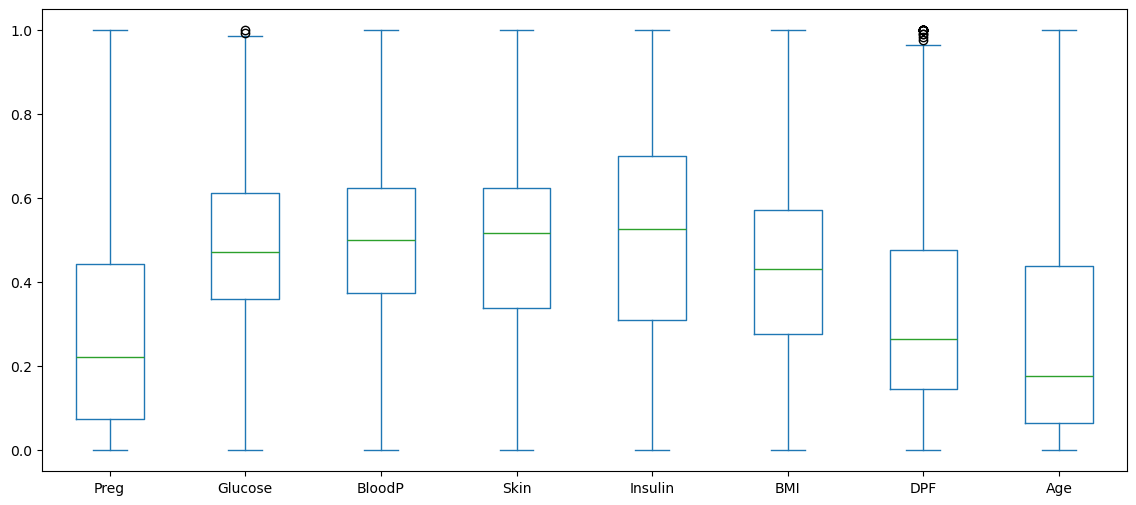

In [28]:
X_train_df.plot(kind="box", figsize=(14,6))

In [29]:
# Standard Normalization
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(X_train) 
X_test_scaled = standard_scaler.transform(X_test) 

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
display.display(X_train_df.describe().round(3).T)

,count,mean,std,min,25%,50%,75%,max
Preg,537.0,-0.0,1.001,-1.153,-0.843,-0.222,0.709,3.037
Glucose,537.0,0.0,1.001,-2.588,-0.729,-0.164,0.567,2.559
BloodP,537.0,0.0,1.001,-2.740,-0.700,-0.020,0.659,2.699
Skin,537.0,-0.0,1.001,-1.870,-0.609,0.054,0.452,1.846
Insulin,537.0,0.0,1.001,-1.498,-0.597,0.034,0.540,1.409
BMI,537.0,0.0,1.001,-2.079,-0.759,-0.032,0.636,2.676
DPF,537.0,-0.0,1.001,-1.328,-0.751,-0.281,0.560,2.640
Age,537.0,0.0,1.001,-1.046,-0.785,-0.350,0.695,2.915


<Axes: >

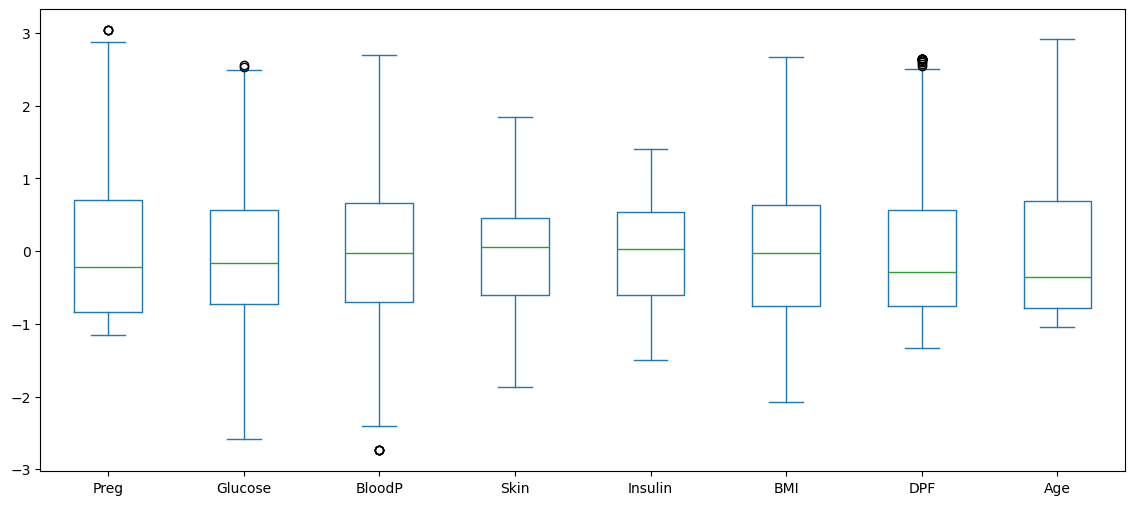

In [30]:
X_train_df.plot(kind="box", figsize=(14,6))

##### * **Nhận thấy sau khi xử lý missing value và outliers xong thì các boxplot trở nên đồng đều hơn khi chuẩn hóa**

In [31]:
# Lưu thông tin
save_dir = "exps/pima-indians-diabetes"
if os.path.exists(save_dir) == False: os.makedirs(save_dir)

# Save training data
np.savez(f'{save_dir}/data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
# Save cleaning data
dataset_clean.to_excel(f'{save_dir}/dataset_clean.xlsx', index=False)
# Save encoders
joblib.dump(class_encoder, f'{save_dir}/class_encoder.joblib')

os.listdir(save_dir)

['class_encoder.joblib', 'data.npz', 'dataset_clean.xlsx']

In [32]:
# Kiểm tra hồi phục dữ liệu
dict(np.load(f'{save_dir}/data.npz')).keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])

In [33]:
pd.read_excel(f'{save_dir}/dataset_clean.xlsx')

,Preg,Glucose,BloodP,Skin,Insulin,BMI,DPF,Age,Outcome
0,6.0,148,72,35.0,125.000,33.6,0.627,50.0,1
1,1.0,85,66,29.0,125.000,26.6,0.351,31.0,0
2,8.0,183,64,29.0,125.000,23.3,0.672,32.0,1
3,1.0,89,66,23.0,112.875,28.1,0.167,21.0,0
4,0.0,137,40,35.0,135.875,43.1,1.200,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101,76,42.5,135.875,32.9,0.171,63.0,0
764,2.0,122,70,27.0,125.000,36.8,0.340,27.0,0
765,5.0,121,72,23.0,112.875,26.2,0.245,30.0,0
766,1.0,126,60,29.0,125.000,30.1,0.349,47.0,1


In [34]:
joblib.load(f'{save_dir}/class_encoder.joblib').classes_

array([0, 1])

## So sánh tổng quan giữa dữ liệu gốc và dữ liệu sau khi chuẩn bị:

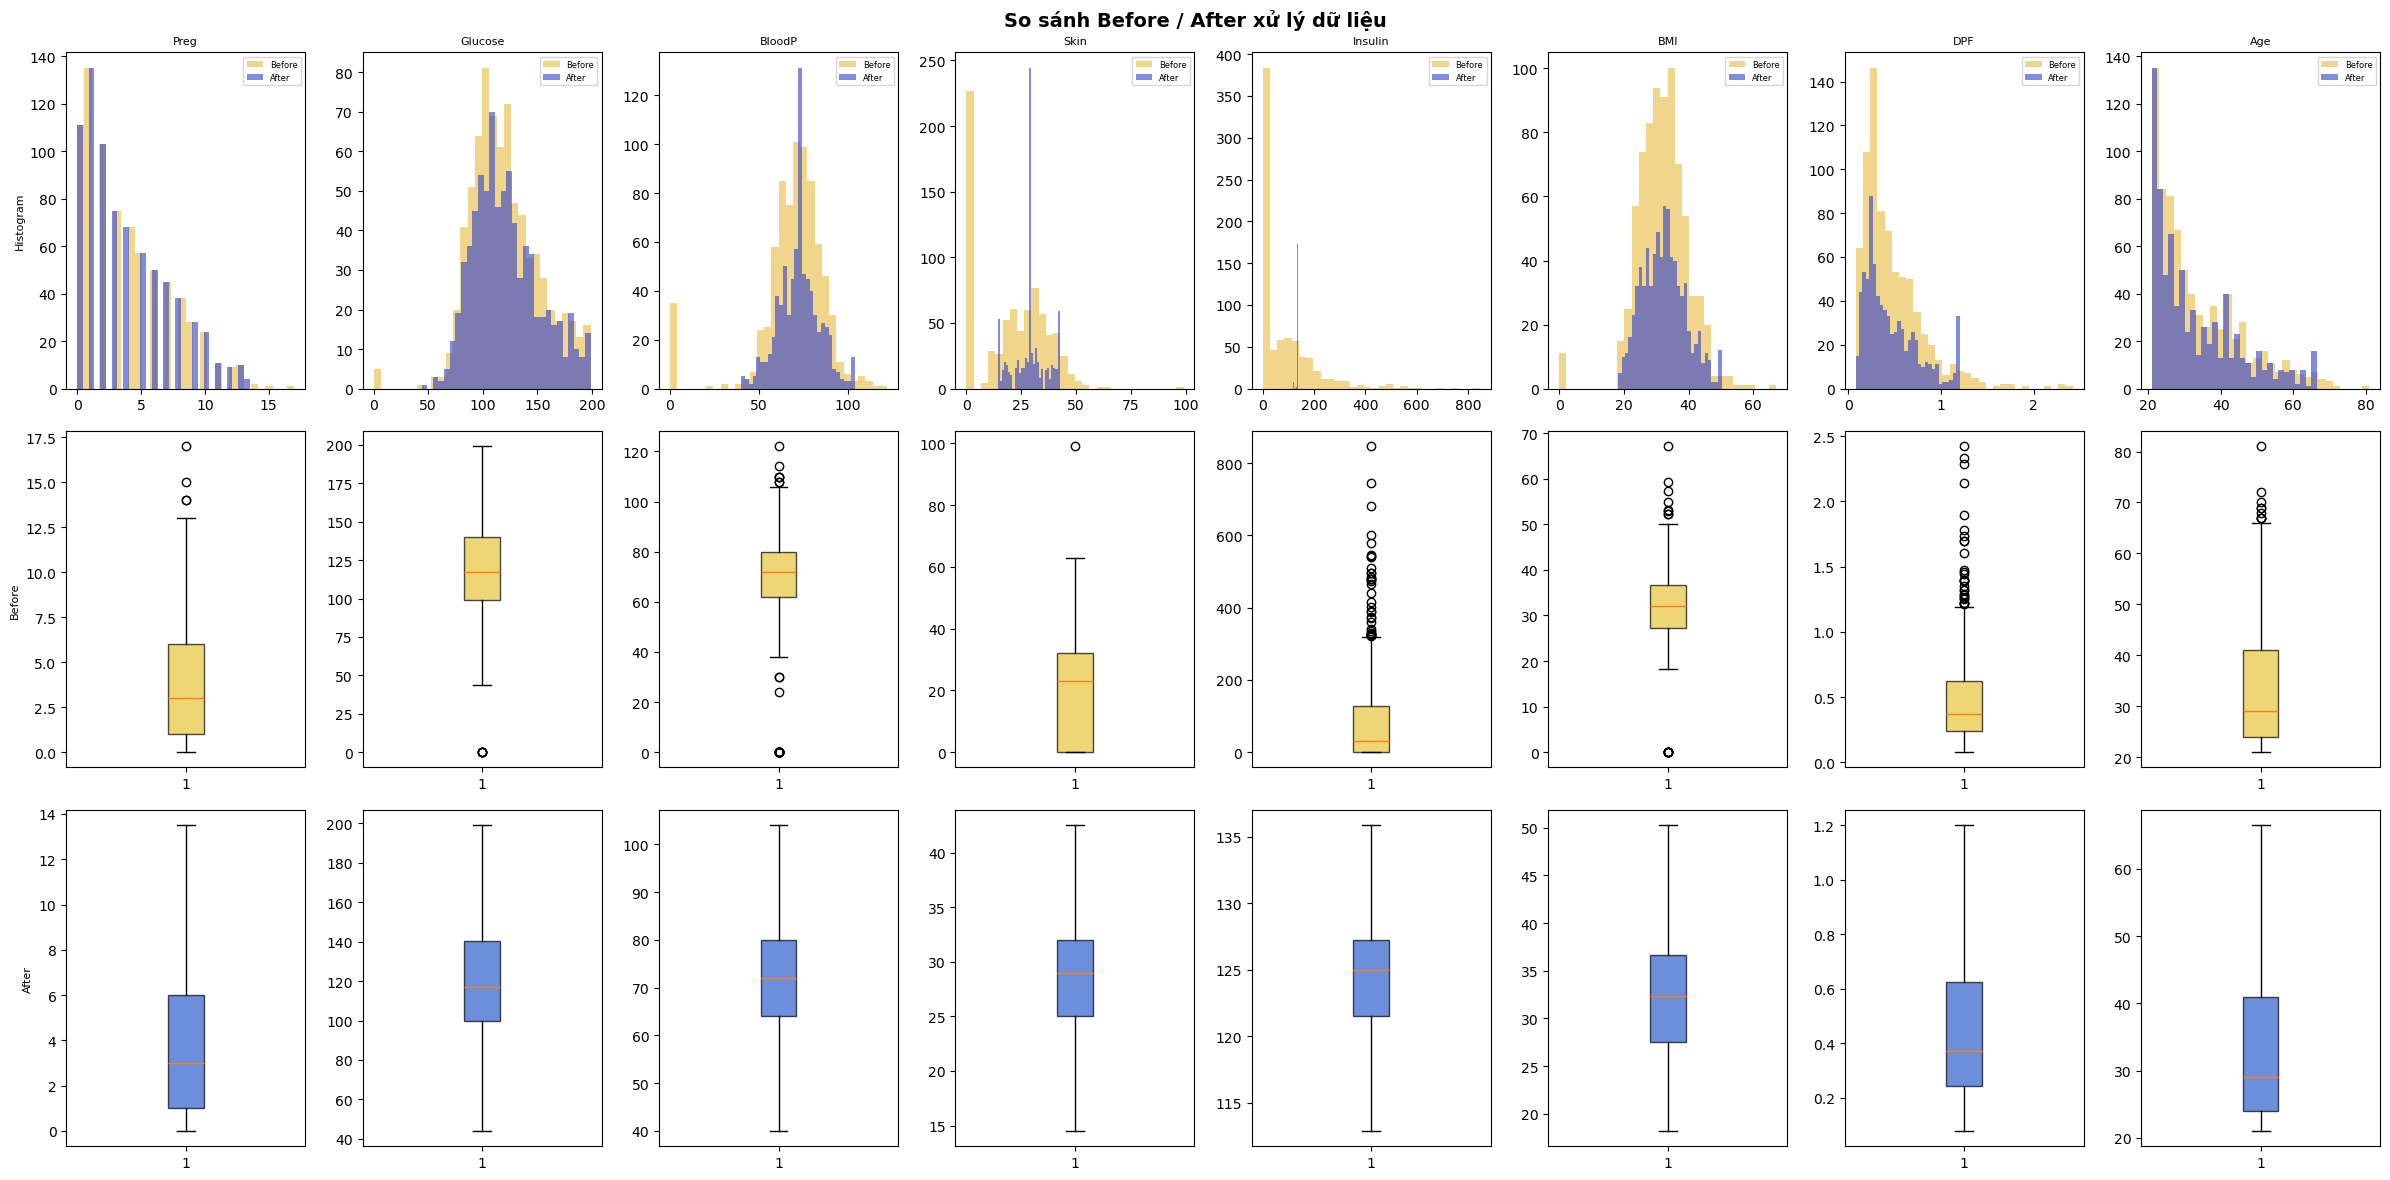

In [35]:
# by Claude
def compare_before_after(df_before, df_after, feature_cols):
    fig, axes = plt.subplots(3, len(feature_cols), figsize=(24, 12))
    fig.suptitle('So sánh Before / After xử lý dữ liệu', fontsize=14, fontweight='bold')

    for i, col in enumerate(feature_cols):
        # Hàng 1: Histogram
        axes[0, i].hist(df_before[col], bins=30, color="#e7b93c", alpha=0.6, label='Before')
        axes[0, i].hist(df_after[col], bins=30, color="#2e3ecc", alpha=0.6, label='After')
        axes[0, i].set_title(col, fontsize=8)
        axes[0, i].legend(fontsize=6)
        if i == 0:
            axes[0, i].set_ylabel('Histogram', fontsize=8)

        # Hàng 2: Boxplot Before
        axes[1, i].boxplot(df_before[col], patch_artist=True,
            boxprops={'facecolor': "#e7c53c", 'alpha': 0.7})
        if i == 0:
            axes[1, i].set_ylabel('Before', fontsize=8)

        # Hàng 3: Boxplot After
        axes[2, i].boxplot(df_after[col], patch_artist=True,
            boxprops={'facecolor': "#2e60cc", 'alpha': 0.7})
        if i == 0:
            axes[2, i].set_ylabel('After', fontsize=8)

    plt.tight_layout()
    plt.savefig('compare_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

# Gọi hàm
feature_cols = ['Preg', 'Glucose', 'BloodP', 'Skin', 'Insulin', 'BMI', 'DPF', 'Age']
compare_before_after(dataset, dataset_clean, feature_cols)

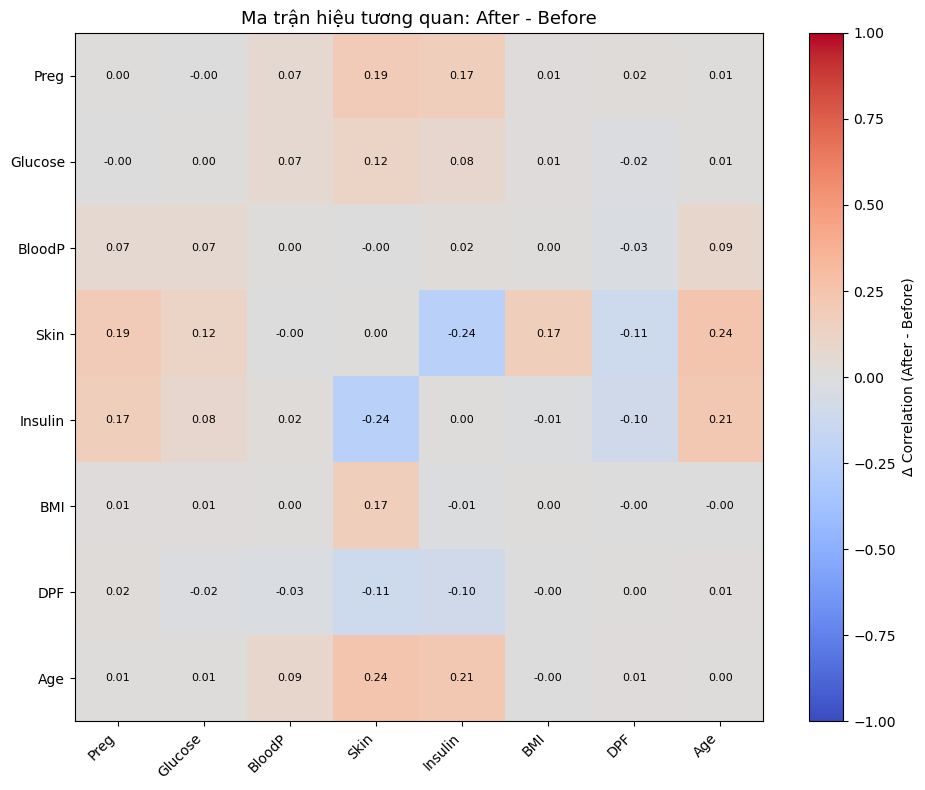

In [40]:
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)  # thêm vmin/vmax
plt.colorbar(label='Δ Correlation (After - Before)')
plt.title('Ma trận hiệu tương quan: After - Before', fontsize=13)
plt.xticks(np.arange(n), cols, rotation=45, ha='right')
plt.yticks(np.arange(n), cols)

# Thêm giá trị vào từng ô
for i in range(n):
    for j in range(n):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Kết thúc
